# Hypothesis 1 — fast agents mainly interact with each other

A minimal agent-based model matching the LaTeX spec:

- `n × n` grid with edges (no wrap-around), Moore neighbourhood (8 neighbours)
- Two agent **types**, fast and slow, half each, placed at random. Types never change.
- Each agent holds a **label**: `F` (fast-origin information) or `S` (slow-origin). Everyone starts with their own type's label.
- **Push dynamics.** When an agent takes a turn it offers its label to all 8 neighbours. Each neighbour independently accepts with probability `p`.
- **Speed.** Fast agents take a turn every tick. Slow agents take a turn every `rho` ticks, so `rho = ΔT_s / ΔT_f`.
- **"Interaction"** = one successful adoption event (an offer that was accepted). We count them in a 2×2 table by (propagator type, adopter type).

Prediction from the counting argument (balanced population, any `p`, any `n`):

| quantity | formula | ρ=1 | ρ=3 | ρ=10 | ρ=100 |
|---|---|---|---|---|---|
| share of events that are fast→fast, σ_ff | ρ / 2(ρ+1) | 0.250 | 0.375 | 0.455 | 0.495 |
| share of events *started* by a fast agent, σ_f· | ρ / (ρ+1) | 0.500 | 0.750 | 0.909 | 0.990 |
| share of events *received* by a fast agent | ½ | 0.500 | 0.500 | 0.500 | 0.500 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

FAST, SLOW = 0, 1          # agent type (fixed)
F, S = 0, 1                # information label (changes)

# the 8 Moore-neighbourhood offsets (row shift, column shift)
OFFSETS = [(di, dj) for di in (-1, 0, 1) for dj in (-1, 0, 1) if (di, dj) != (0, 0)]

## 1. Build the grid

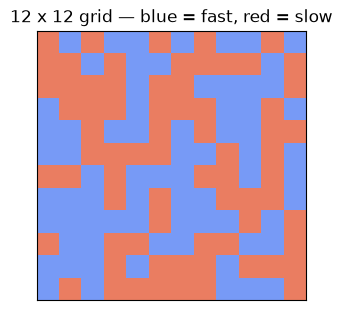

In [2]:
def make_grid(n, rng):
    """n x n grid, half fast / half slow at random. Everyone starts holding their own type's label."""
    kind = np.full(n * n, SLOW, dtype=int)
    kind[: n * n // 2] = FAST
    rng.shuffle(kind)
    kind = kind.reshape(n, n)
    state = np.where(kind == FAST, F, S)
    return kind, state

rng = np.random.default_rng(0)
kind, state = make_grid(12, rng)

plt.figure(figsize=(3.5, 3.5))
plt.imshow(kind, cmap="coolwarm", vmin=-0.3, vmax=1.3)
plt.title("12 x 12 grid — blue = fast, red = slow")
plt.xticks([]); plt.yticks([])
plt.show()

## 2. Neighbours without wrap-around

For an offset `(di, dj)`, `src` selects the agents that *offer* and `dst` selects the neighbours that *receive*.
Both slices are trimmed so nothing falls off the edge of the grid — that is the whole boundary treatment.

In [8]:
def inside(n, di, dj):
    """Slices so that grid[src] offers to grid[dst] for offset (di, dj), staying inside the n x n grid."""
    r0, r1 = max(0, -di), n - max(0, di)
    c0, c1 = max(0, -dj), n - max(0, dj)
    src = (slice(r0, r1), slice(c0, c1))
    dst = (slice(r0 + di, r1 + di), slice(c0 + dj, c1 + dj))
    return src, dst

# quick check: a corner agent should have 3 neighbours, an edge agent 5, an interior agent 8
n = 5
degree = np.zeros((n, n), dtype=int)
for di, dj in OFFSETS:
    src, dst = inside(n, di, dj)
    degree[src] += 1
print(degree)

[[3 5 5 5 3]
 [5 8 8 8 5]
 [5 8 8 8 5]
 [5 8 8 8 5]
 [3 5 5 5 3]]


## 3. One simulation

Each tick:
1. work out who is active (fast: always; slow: every `rho` ticks, with a random phase so they don't all fire together)
2. every active agent offers its label to all 8 neighbours; each offer is accepted with probability `p`
3. count each accepted offer in `events[propagator type, adopter type]`
4. adopters copy the propagator's label

Step 4 is what makes it an information-spreading model, but note the Hypothesis 1 numbers only depend on steps 1–3.

In [9]:
def simulate(n, rho, p, slow_steps, seed=0):
    """Run for `slow_steps` slow time steps (= slow_steps * rho ticks).
    Returns events[propagator type, adopter type] and the final grid."""
    rng = np.random.default_rng(seed)
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    events = np.zeros((2, 2), dtype=int)

    for t in range(slow_steps * rho):
        active = (kind == FAST) | ((t + phase) % rho == 0)
        new_state = state.copy()
        for di, dj in OFFSETS:
            src, dst = inside(n, di, dj)
            accepted = active[src] & (rng.random(active[src].shape) < p)
            for a in (FAST, SLOW):
                for b in (FAST, SLOW):
                    events[a, b] += np.count_nonzero(accepted & (kind[src] == a) & (kind[dst] == b))
            target = new_state[dst]                  # a view into new_state
            target[accepted] = state[src][accepted]  # adopter copies the propagator's label
        state = new_state
    return events, kind, state

events, kind, state = simulate(n=40, rho=3, p=0.1, slow_steps=5, seed=1)
print("events[propagator, adopter]  (rows: fast, slow / cols: fast, slow)")
print(events)
print()
print(f"share fast->fast        {events[FAST, FAST] / events.sum():.3f}   predicted {3/(2*4):.3f}")
print(f"share started by fast   {events[FAST].sum() / events.sum():.3f}   predicted {3/4:.3f}")
print(f"share received by fast  {events[:, FAST].sum() / events.sum():.3f}   predicted 0.500")

events[propagator, adopter]  (rows: fast, slow / cols: fast, slow)
[[4576 4514]
 [1583 1489]]

share fast->fast        0.376   predicted 0.375
share started by fast   0.747   predicted 0.750
share received by fast  0.506   predicted 0.500


## 4. The 2×2 table at ρ = 3 against the prediction

With 100+100 agents, the LaTeX worked example predicts 120 : 120 : 40 : 40 per slow time step. The grid above has 800+800 agents and ran for 5 slow steps, so we compare shares rather than raw counts.

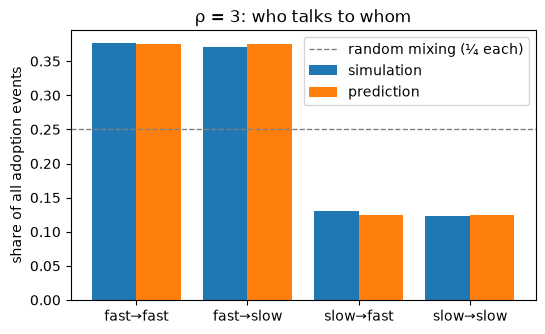

In [10]:
labels = ["fast→fast", "fast→slow", "slow→fast", "slow→slow"]
observed = events.flatten() / events.sum()
predicted3 = np.array([3, 3, 1, 1]) / 8          # 2ρNp : 2ρNp : 2Np : 2Np with ρ = 3

x = np.arange(4)
plt.figure(figsize=(6, 3.5))
plt.bar(x - 0.2, observed, 0.4, label="simulation")
plt.bar(x + 0.2, predicted3, 0.4, label="prediction")
plt.axhline(0.25, color="grey", linestyle="--", linewidth=1, label="random mixing (¼ each)")
plt.xticks(x, labels)
plt.ylabel("share of all adoption events")
plt.title("ρ = 3: who talks to whom")
plt.legend()
plt.show()

## 5. Sweep the speed ratio ρ ∈ {1, 3, 10, 100}

rho =   1   fast->fast 0.249   started by fast 0.503   received by fast 0.505
rho =   3   fast->fast 0.376   started by fast 0.747   received by fast 0.506
rho =  10   fast->fast 0.454   started by fast 0.908   received by fast 0.501
rho = 100   fast->fast 0.491   started by fast 0.990   received by fast 0.496


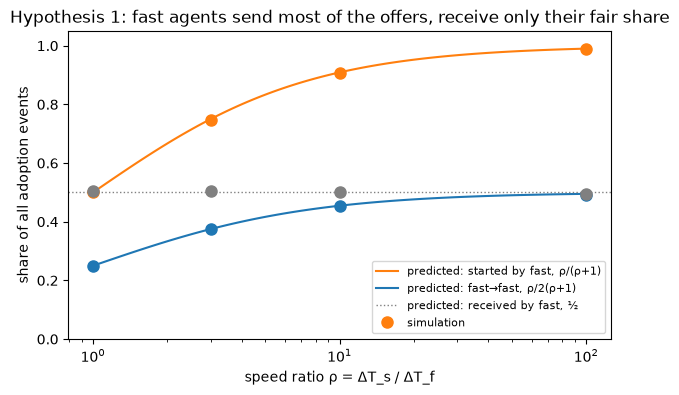

In [11]:
RHOS = [1, 3, 10, 100]
ff_share, fast_started, fast_received = [], [], []

for rho in RHOS:
    ev, _, _ = simulate(n=40, rho=rho, p=0.1, slow_steps=5, seed=1)
    tot = ev.sum()
    ff_share.append(ev[FAST, FAST] / tot)
    fast_started.append(ev[FAST].sum() / tot)
    fast_received.append(ev[:, FAST].sum() / tot)
    print(f"rho = {rho:3d}   fast->fast {ff_share[-1]:.3f}   started by fast {fast_started[-1]:.3f}   received by fast {fast_received[-1]:.3f}")

rho_line = np.logspace(0, 2, 100)
plt.figure(figsize=(7, 4))
plt.plot(rho_line, rho_line / (rho_line + 1), color="C1", label="predicted: started by fast, ρ/(ρ+1)")
plt.plot(rho_line, rho_line / (2 * (rho_line + 1)), color="C0", label="predicted: fast→fast, ρ/2(ρ+1)")
plt.axhline(0.5, color="grey", linestyle=":", linewidth=1, label="predicted: received by fast, ½")
plt.plot(RHOS, fast_started, "o", color="C1", markersize=8, label="simulation")
plt.plot(RHOS, ff_share, "o", color="C0", markersize=8)
plt.plot(RHOS, fast_received, "o", color="grey", markersize=8)
plt.xscale("log")
plt.xlabel("speed ratio ρ = ΔT_s / ΔT_f")
plt.ylabel("share of all adoption events")
plt.ylim(0, 1.05)
plt.title("Hypothesis 1: fast agents send most of the offers, receive only their fair share")
plt.legend(loc="lower right", fontsize=8)
plt.show()

## Reading the result

- At **ρ = 1** all four kinds of event are equally common (¼ each): random mixing, the control.
- As ρ grows, the share of events *started* by a fast agent climbs towards 1 and the fast→fast share towards ½, both exactly as the counting argument predicts.
- The share of events *received* by fast agents stays at ½ for every ρ. Nothing in the model makes fast agents preferentially chosen as partners; they simply take more turns. This is the same conclusion as the LaTeX: **fast agents don't receive more than their share — they send more than their share.**
- `n` and `p` cancel in the predictions, and you can verify this by changing them in `simulate`.

## 6. The $\mathcal{C}$-index

The LaTeX defines the outcome measure as the share of slow-origin information relative to the share of slow agents:

$$
\mathcal{C} \;=\; \frac{\mathbb{E}[n_S(T)] \,/\, \mathbb{E}[n_F(T)]}{N_s / N_f}
        \;=\; \frac{\text{slow-origin information} / \text{fast-origin information}}{\text{number of slow agents} / \text{number of fast agents}} .
$$

$\mathcal{C} < 1$ means fast-origin information outcompetes slow-origin information relative to the population mix; $\mathcal{C} = 1$ is proportional representation; $\mathcal{C} > 1$ means slow-origin information wins. The population here is balanced ($N_s = N_f$), so the denominator is 1 and $\mathcal{C}$ is just $\mathbb{E}[n_S]/\mathbb{E}[n_F]$.

The analytic prediction under uniform $p$ is

$$
\mathcal{C} \;=\; \frac{r_s\, P_{sf}}{r_f\, P_{fs}} \;=\; \frac{P_{sf}}{\rho\, P_{fs}} \;=\; \frac{1}{\rho},
$$

independent of $p$, $n$ and $f$: **every doubling of the speed ratio halves the representation of slow-origin information.**

### Measuring it "when time is appropriately long"

$\mathcal{C}$ is defined at a long horizon $T$, in expectation over independent runs. Two timescales matter, and they are wildly separated:

- **Mixing time** $\tau = \Delta T_f \,/\, \bigl[k\,p\,(f + (1-f)/\rho)\bigr]$ — how long until $u_f$ and $u_s$ stop moving and the label mix goes flat. This is only a couple of ticks.
- **Fixation time** — how long until one label takes over completely. For 2D voter dynamics this is of order $N \log N$ sweeps, i.e. thousands of ticks on a $40\times40$ grid.

So there is a long **plateau** in between: $T \gg \tau$, where the distribution of fast- and slow-origin information is steady, but almost no run has fixated yet. That plateau is where we read $\mathcal{C}$, and where the expectation is cheapest to estimate — waiting longer does not move the mean, it only inflates the variance as runs drift towards consensus.

In [12]:
def simulate_trace(n, rho, ticks, P, seed):
    """Same dynamics as `simulate`, but records n_S every tick and takes a full
    2x2 acceptance matrix P[propagator type, adopter type] rather than a scalar p.
    (That matrix is the knob Hypothesis 3 turns; here every entry is p.)"""
    rng = np.random.default_rng(seed)
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    nS = np.empty(ticks + 1, dtype=int)
    nS[0] = np.count_nonzero(state == S)

    for t in range(ticks):
        active = (kind == FAST) | ((t + phase) % rho == 0)
        new_state = state.copy()
        for di, dj in OFFSETS:
            src, dst = inside(n, di, dj)
            prob = P[kind[src], kind[dst]]                # per-pair acceptance probability
            accepted = active[src] & (rng.random(prob.shape) < prob)
            target = new_state[dst]
            target[accepted] = state[src][accepted]
        state = new_state
        nS[t + 1] = np.count_nonzero(state == S)
    return nS


def tau_ticks(rho, p=0.1, k=8, f=0.5):
    """Mixing timescale in units of the fast tick, eq. (tau) in the LaTeX."""
    return 1.0 / (k * p * (f + (1 - f) / rho))


N_SIDE, P_SCALAR, SEEDS, T_HORIZON = 40, 0.1, 200, 60
N = N_SIDE ** 2
P_UNIFORM = np.full((2, 2), P_SCALAR)           # P_ff = P_fs = P_sf = P_ss = p
RHOS_C = [1, 2, 3, 5, 10, 30, 100]

print(f"horizon T = {T_HORIZON} ticks, {SEEDS} seeds, {N_SIDE}x{N_SIDE} grid, p = {P_SCALAR}\n")
for rho in RHOS_C:
    print(f"  rho = {rho:3d}   tau = {tau_ticks(rho):.2f} ticks   T/tau = {T_HORIZON / tau_ticks(rho):5.1f}")

horizon T = 60 ticks, 200 seeds, 40x40 grid, p = 0.1

  rho =   1   tau = 1.25 ticks   T/tau =  48.0
  rho =   2   tau = 1.67 ticks   T/tau =  36.0
  rho =   3   tau = 1.88 ticks   T/tau =  32.0
  rho =   5   tau = 2.08 ticks   T/tau =  28.8
  rho =  10   tau = 2.27 ticks   T/tau =  26.4
  rho =  30   tau = 2.42 ticks   T/tau =  24.8
  rho = 100   tau = 2.48 ticks   T/tau =  24.2


### 6.1 The plateau

Run the sweep and look at the fraction of the population holding slow-origin information over time. The dashed lines are the mean-field limit $1 - u^\ast = 1/(\rho+1)$.

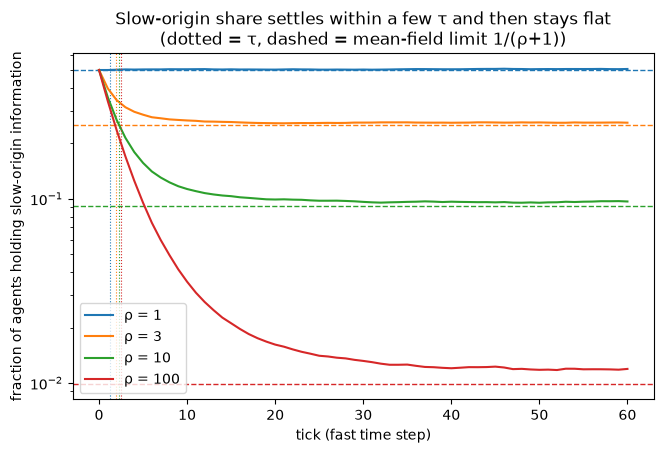

mean slow-origin fraction, showing the plateau is flat:
  rho       t=5      t=10      t=20      t=40      t=60   1/(ρ+1)
    1    0.5036    0.5048    0.5026    0.5047    0.5066    0.5000
    3    0.2860    0.2661    0.2571    0.2587    0.2588    0.2500
   10    0.1565    0.1129    0.0991    0.0964    0.0966    0.0909
  100    0.0951    0.0354    0.0162    0.0120    0.0119    0.0099


In [13]:
traces = {rho: np.array([simulate_trace(N_SIDE, rho, T_HORIZON, P_UNIFORM, seed)
                         for seed in range(SEEDS)])
          for rho in RHOS_C}

plt.figure(figsize=(7.5, 4.5))
for i, rho in enumerate([1, 3, 10, 100]):
    mean_frac = traces[rho].mean(axis=0) / N
    plt.plot(mean_frac, color=f"C{i}", label=f"ρ = {rho}")
    plt.axhline(1 / (rho + 1), color=f"C{i}", linestyle="--", linewidth=1)
    plt.axvline(tau_ticks(rho), color=f"C{i}", linestyle=":", linewidth=0.8)
plt.yscale("log")
plt.xlabel("tick (fast time step)")
plt.ylabel("fraction of agents holding slow-origin information")
plt.title("Slow-origin share settles within a few τ and then stays flat\n"
          "(dotted = τ, dashed = mean-field limit 1/(ρ+1))")
plt.legend()
plt.show()

print("mean slow-origin fraction, showing the plateau is flat:")
print(f"{'rho':>5}" + "".join(f"{f't={t}':>10}" for t in (5, 10, 20, 40, 60)) + f"{'1/(ρ+1)':>10}")
for rho in [1, 3, 10, 100]:
    row = "".join(f"{traces[rho][:, t].mean() / N:10.4f}" for t in (5, 10, 20, 40, 60))
    print(f"{rho:5d}{row}{1 / (rho + 1):10.4f}")

### 6.2 $\mathcal{C}$ at the horizon

$\mathcal{C}$ is a ratio of expectations, so it is estimated as $\overline{n_S}/\overline{n_F}$ across seeds — not as the average of the per-run ratio. Confidence intervals come from bootstrapping over seeds.

  rho  slow-origin share  C (observed)              95% CI   C = 1/rho   ratio
    1             0.5066        1.0266   [0.9872, 1.0664]      1.0000    1.03
    2             0.3445        0.5255   [0.5045, 0.5477]      0.5000    1.05
    3             0.2588        0.3491   [0.3345, 0.3644]      0.3333    1.05
    5             0.1744        0.2112   [0.2005, 0.2216]      0.2000    1.06
   10             0.0966        0.1070   [0.1005, 0.1139]      0.1000    1.07
   30             0.0321        0.0332   [0.0303, 0.0363]      0.0333    1.00
  100             0.0119        0.0121   [0.0102, 0.0138]      0.0100    1.21


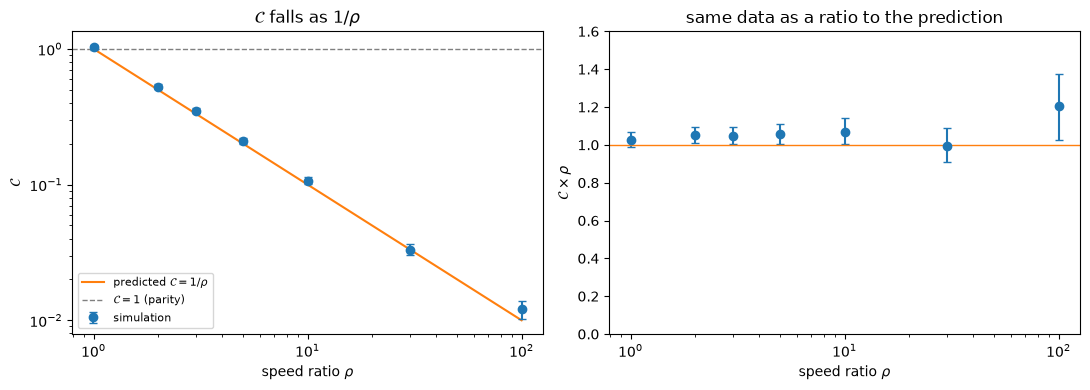

In [14]:
def c_index(nS_at_T, N, n_boot=2000, rng=None):
    """C = E[n_S]/E[n_F] / (N_s/N_f), balanced population so the denominator is 1.
    Returns the point estimate and a bootstrap 95% interval over seeds."""
    rng = np.random.default_rng(0) if rng is None else rng
    nS = np.asarray(nS_at_T, dtype=float)
    C = nS.mean() / (N - nS.mean())
    draws = nS[rng.integers(0, nS.size, size=(n_boot, nS.size))].mean(axis=1)
    lo, hi = np.percentile(draws / (N - draws), [2.5, 97.5])
    return C, lo, hi


rng_boot = np.random.default_rng(12345)
C_hat, C_lo, C_hi = [], [], []

print(f"{'rho':>5}{'slow-origin share':>19}{'C (observed)':>14}{'95% CI':>20}{'C = 1/rho':>12}{'ratio':>8}")
for rho in RHOS_C:
    nS_T = traces[rho][:, T_HORIZON]
    C, lo, hi = c_index(nS_T, N, rng=rng_boot)
    C_hat.append(C); C_lo.append(lo); C_hi.append(hi)
    print(f"{rho:5d}{nS_T.mean() / N:19.4f}{C:14.4f}   [{lo:6.4f}, {hi:6.4f}]{1 / rho:12.4f}{C * rho:8.2f}")

C_hat, C_lo, C_hi = map(np.array, (C_hat, C_lo, C_hi))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

rho_line = np.logspace(0, 2, 100)
ax[0].plot(rho_line, 1 / rho_line, color="C1", label=r"predicted $\mathcal{C} = 1/\rho$")
ax[0].errorbar(RHOS_C, C_hat, yerr=[C_hat - C_lo, C_hi - C_hat], fmt="o",
               color="C0", capsize=3, label="simulation")
ax[0].axhline(1, color="grey", linestyle="--", linewidth=1, label=r"$\mathcal{C}=1$ (parity)")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel(r"speed ratio $\rho$"); ax[0].set_ylabel(r"$\mathcal{C}$")
ax[0].set_title(r"$\mathcal{C}$ falls as $1/\rho$")
ax[0].legend(fontsize=8)

ax[1].errorbar(RHOS_C, C_hat * np.array(RHOS_C),
               yerr=[(C_hat - C_lo) * np.array(RHOS_C), (C_hi - C_hat) * np.array(RHOS_C)],
               fmt="o", color="C0", capsize=3)
ax[1].axhline(1, color="C1", linewidth=1)
ax[1].set_xscale("log")
ax[1].set_xlabel(r"speed ratio $\rho$"); ax[1].set_ylabel(r"$\mathcal{C} \times \rho$")
ax[1].set_title(r"same data as a ratio to the prediction")
ax[1].set_ylim(0, 1.6)

plt.tight_layout(); plt.show()

### 6.3 Why $\mathcal{C}$ sits a little above $1/\rho$

The observed $\mathcal{C}$ tracks $1/\rho$ over two decades but runs a few percent high, rising to about $+20\%$ at $\rho = 100$. That is not a bug, and it is not a shortfall of the horizon — it is the lattice.

Proposition 1 says $M(t) = c_f \sum_{i \text{ fast}} \mathbf{1}[x_i = F] + c_s \sum_{i \text{ slow}} \mathbf{1}[x_i = F]$, with $c_f = r_f P_{fs}$ and $c_s = r_s P_{sf}$, is a martingale on *any* graph. Checking $M$ is therefore a direct test of whether the simulation is faithful to the spec. With $N_s = N_f$ it pins

$$u_f + u_s/\rho \;=\; 1 .$$

The mean-field limit $u^\ast = \rho/(\rho+1)$ needs one *extra* assumption on top of that: $u_f = u_s$, i.e. perfect mixing. On a lattice that assumption fails — like-labelled agents form domains, and slow agents stay slightly more slow-labelled than their fast neighbours. The residual gap $u_f - u_s$ never closes, so $n_F/N = (u_f + u_s)/2$ settles just *below* $u^\ast$ and $\mathcal{C}$ just above $1/\rho$.

In [15]:
def simulate_by_type(n, rho, ticks, P, seed):
    """As simulate_trace, but records (# fast holding F, # slow holding F) each tick."""
    rng = np.random.default_rng(seed)
    kind, state = make_grid(n, rng)
    phase = rng.integers(0, rho, size=(n, n))
    is_fast = kind == FAST
    out = np.empty((ticks + 1, 2))
    out[0] = (np.count_nonzero((state == F) & is_fast), np.count_nonzero((state == F) & ~is_fast))

    for t in range(ticks):
        active = is_fast | ((t + phase) % rho == 0)
        new_state = state.copy()
        for di, dj in OFFSETS:
            src, dst = inside(n, di, dj)
            prob = P[kind[src], kind[dst]]
            accepted = active[src] & (rng.random(prob.shape) < prob)
            target = new_state[dst]
            target[accepted] = state[src][accepted]
        state = new_state
        out[t + 1] = (np.count_nonzero((state == F) & is_fast), np.count_nonzero((state == F) & ~is_fast))
    return out


DIAG_SEEDS = 150
print(f"{'rho':>5}{'u_f':>9}{'u_s':>9}{'u_f-u_s':>10}{'u_f+u_s/ρ':>12}{'n_F/N':>9}{'u* ':>9}{'M(T)/M(0)':>12}")
for rho in [3, 10, 100]:
    by_type = np.array([simulate_by_type(N_SIDE, rho, T_HORIZON, P_UNIFORM, seed)
                        for seed in range(DIAG_SEEDS)]).mean(axis=0)
    c_f, c_s = 1.0 * P_SCALAR, (1.0 / rho) * P_SCALAR      # r_f = 1, r_s = 1/rho
    M = c_f * by_type[:, 0] + c_s * by_type[:, 1]
    u_f, u_s = by_type[T_HORIZON] / (N / 2)
    print(f"{rho:5d}{u_f:9.4f}{u_s:9.4f}{u_f - u_s:10.4f}{u_f + u_s / rho:12.4f}"
          f"{(u_f + u_s) / 2:9.4f}{rho / (rho + 1):9.4f}{M[T_HORIZON] / M[0]:12.4f}")

print("\nM(T)/M(0) ≈ 1 confirms the martingale: the simulation matches Proposition 1.")
print("u_f + u_s/ρ ≈ 1 is what the martingale pins; u_f > u_s is the lattice correlation")
print("that mean-field ignores, and it is what lifts C slightly above 1/ρ.")

  rho      u_f      u_s   u_f-u_s   u_f+u_s/ρ    n_F/N      u*    M(T)/M(0)
    3   0.7497   0.7412    0.0086      0.9968   0.7454   0.7500      0.9968
   10   0.9054   0.9001    0.0053      0.9954   0.9028   0.9091      0.9954
  100   0.9903   0.9856    0.0047      1.0001   0.9879   0.9901      1.0001

M(T)/M(0) ≈ 1 confirms the martingale: the simulation matches Proposition 1.
u_f + u_s/ρ ≈ 1 is what the martingale pins; u_f > u_s is the lattice correlation
that mean-field ignores, and it is what lifts C slightly above 1/ρ.


## Reading the $\mathcal{C}$-index result

- $\mathcal{C}$ measured on the plateau reproduces the $1/\rho$ law across two decades of speed ratio. At $\rho = 1$ it sits at parity ($\mathcal{C} \approx 1$); by $\rho = 100$ slow-origin information holds barely $1\%$ of the population despite slow agents being *half* of it.
- The plateau is reached within a handful of ticks — on the **fast** agents' clock, essentially independent of $\rho$ — so the crowding-out is not a slow grind. It is settled before slow agents have taken more than a turn or two.
- Waiting longer does not change the answer, only the error bars: the mean is flat from $t \approx 25$ onward, while variance grows as runs drift towards fixation. There is no benefit to running to consensus if all you want is $\mathcal{C}$.
- The martingale check ($M(T)/M(0) \approx 1$) confirms the implementation matches Proposition 1. The residual few-percent excess of $\mathcal{C}$ over $1/\rho$ is a genuine lattice effect — spatial correlations keep $u_f > u_s$ — and it is *in favour of* slow agents, so the mean-field prediction is, if anything, a slight overstatement of how badly slow-origin information is crowded out.
- `simulate_trace` takes the full $2\times2$ matrix $P_{ab}$, so Hypothesis 3 is a parameter change rather than a rewrite: raising $P_{sf}$ above $p$ should move $\mathcal{C}$ along $\mathcal{C} = P_{sf}/(\rho\, P_{fs})$ and cross parity at $P_{sf}^\ast = \rho\, P_{fs}$.